In [20]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
from sympy import symbols, lambdify
from sympy import symbols, hermite
from torch.distributions import Normal
from numpy.polynomial.hermite import Hermite, herm2poly
import torch.nn.functional as F

In [21]:
num_train_functions = 1000  
train_iterations    = 10000  
test_functions      = 10  
num_train_functions = 10  
train_iterations    = 1000  
test_functions      = 3  


In [22]:

# ─────────────────────────────────────────────────────────────────────────────
# 0) Device selection: use GPU if available, else CPU
# ─────────────────────────────────────────────────────────────────────────────
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# ─────────────────────────────────────────────────────────────────────────────
# 1) Hermite polynomials H0…H3 (physicists’ version)
# ─────────────────────────────────────────────────────────────────────────────
def hermite_polynomials(x):
    """
    Computes H0(x), H1(x), H2(x), H3(x) (physicists’ Hermite):
      H0(x) = 1
      H1(x) = 2x
      H2(x) = 4x^2 – 2
      H3(x) = 8x^3 – 12x
    Input:
      x : tensor of shape (batch_size,) or any shape on the correct device
    Returns:
      tensor of shape (..., 4), where the last dimension indexes H0..H3.
    """
    H0 = torch.ones_like(x)
    H1 = 2.0 * x
    H2 = 4.0 * x**2 - 2.0
    H3 = 8.0 * x**3 - 12.0 * x
    return torch.stack([H0, H1, H2, H3], dim=-1)  # shape (..., 4)

# ─────────────────────────────────────────────────────────────────────────────
# 2) Sample a random “Hermite‐based” function f(x)
# ─────────────────────────────────────────────────────────────────────────────
def sample_hermite_function(device):
    """
    Samples random coefficients c0..c3 ~ Normal(0, sqrt(2)) on the given device,
    and returns a Python‐callable f(x) that evaluates c_i * H_i(x).
    """
    coeffs = torch.normal(
        mean=0.0,
        std=torch.sqrt(torch.tensor(2.0, device=device)),
        size=(4,),
        device=device
    )

    def f(x):
        # x is assumed to be a 1D tensor on the same device
        H = hermite_polynomials(x)     # shape (N, 4)
        return (H * coeffs).sum(dim=-1) # shape (N,)
    return f

Using device: mps


Training on device: mps


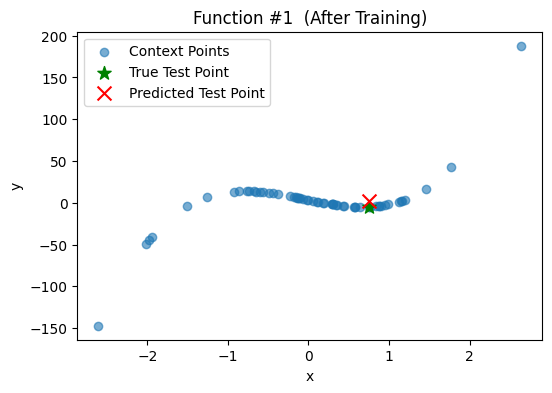

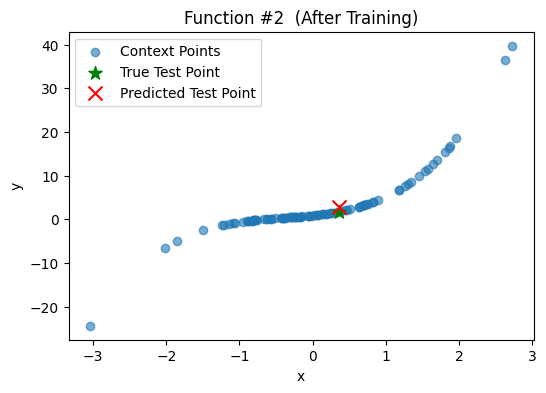

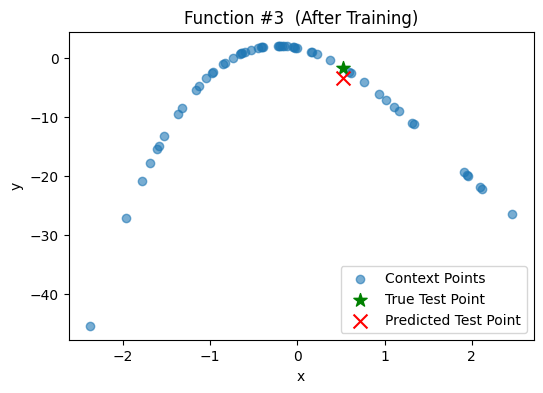

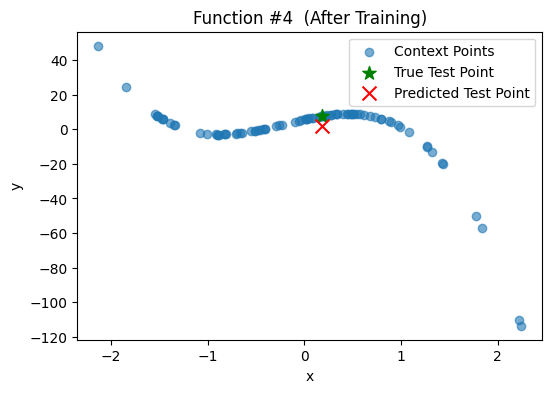

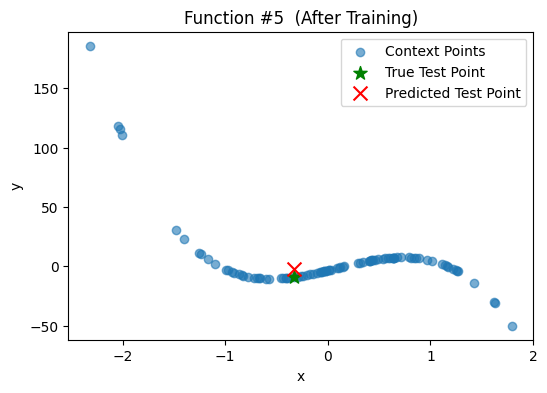

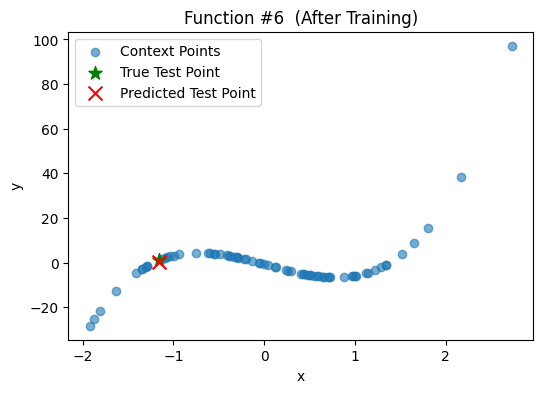

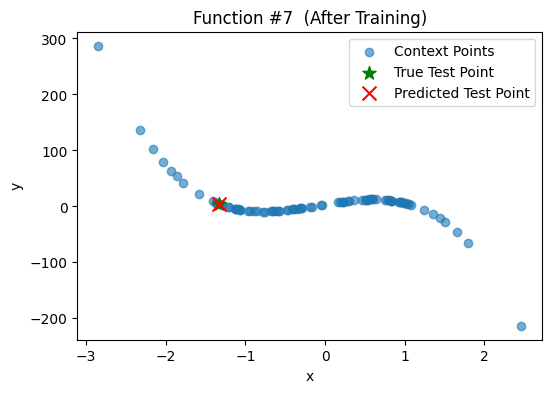

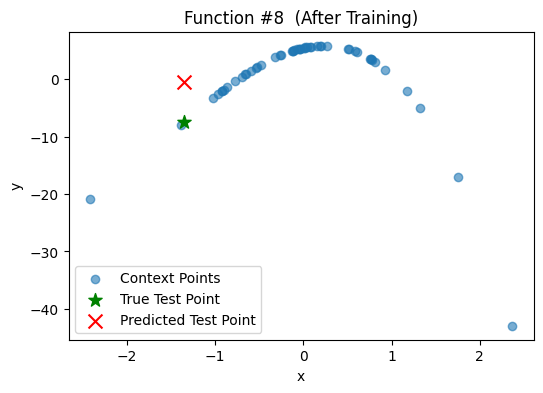

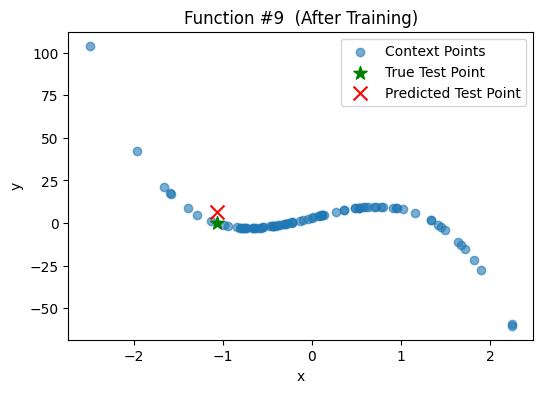

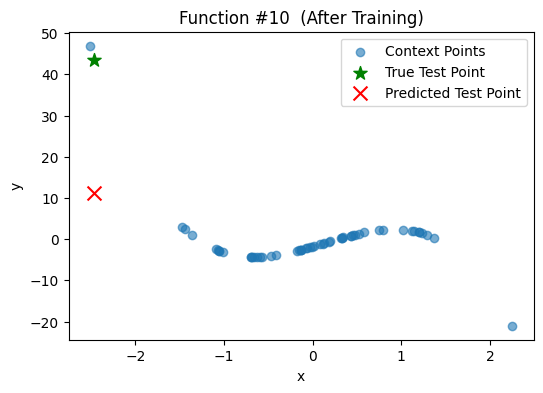

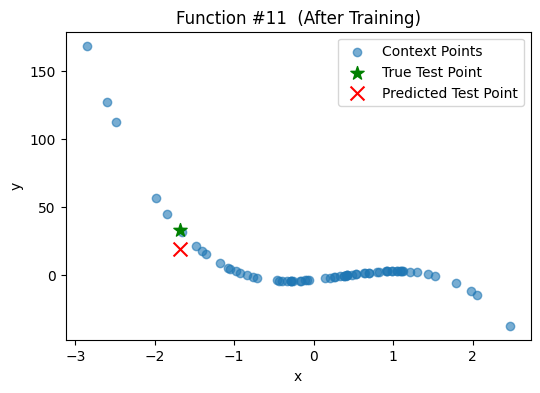

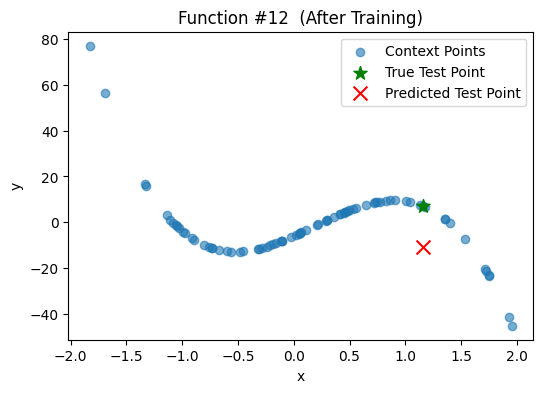

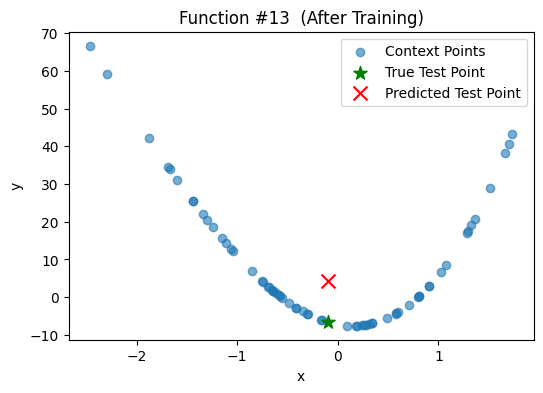

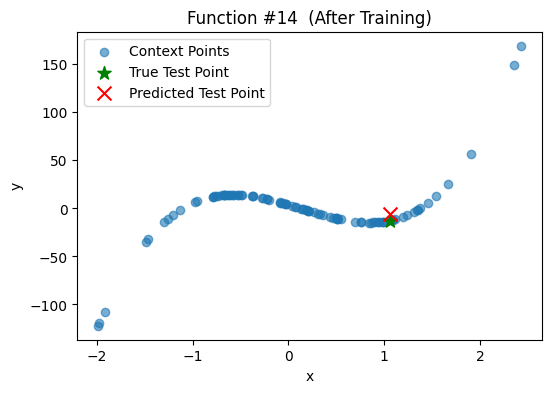

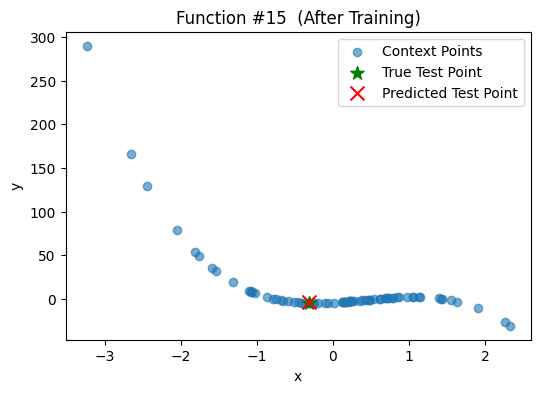

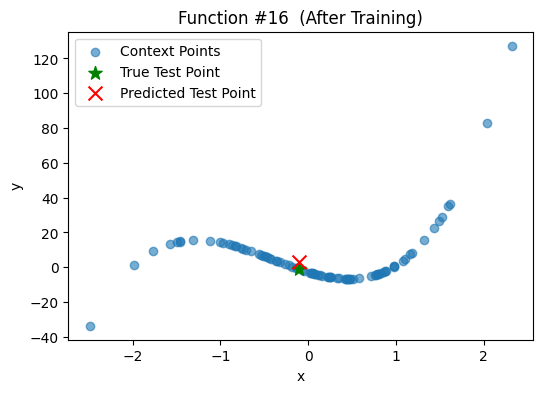

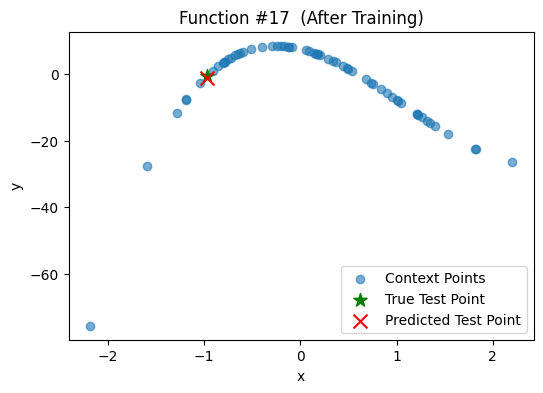

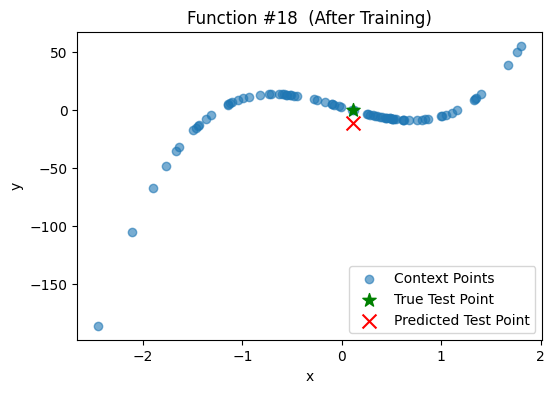

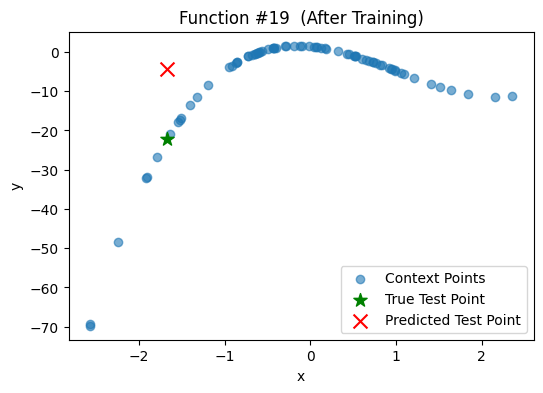

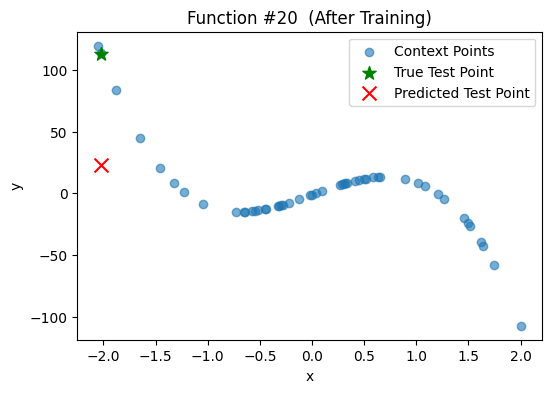

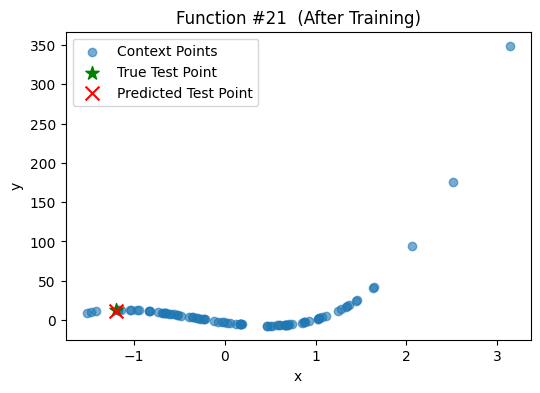

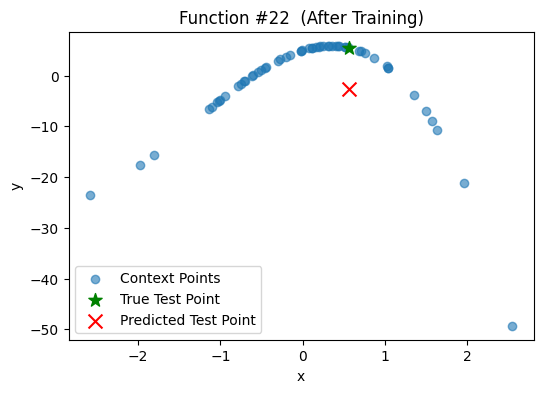

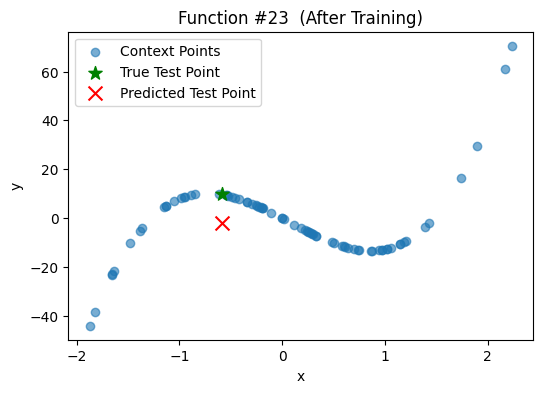

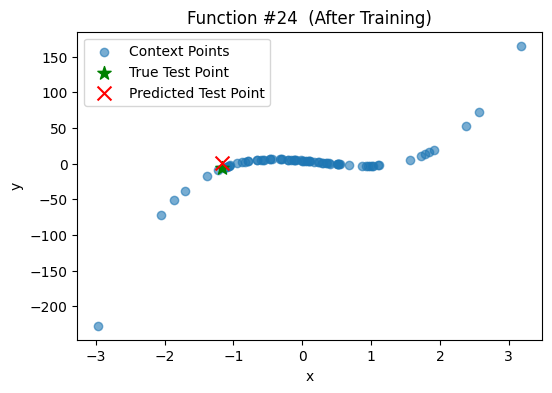

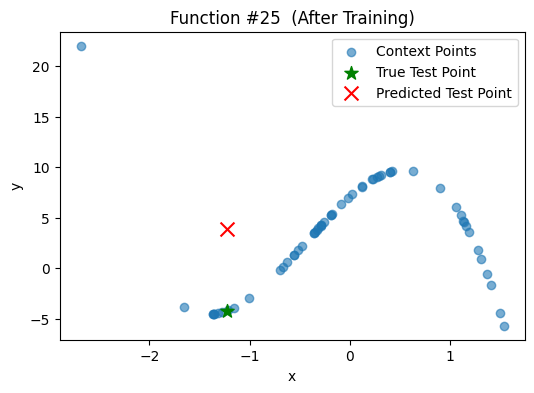

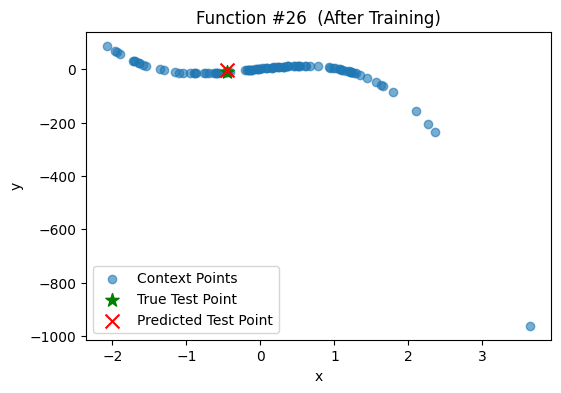

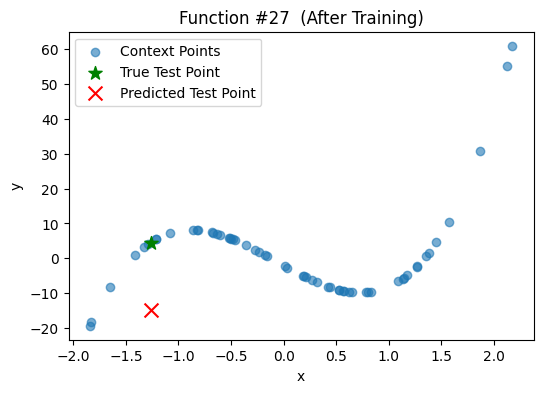

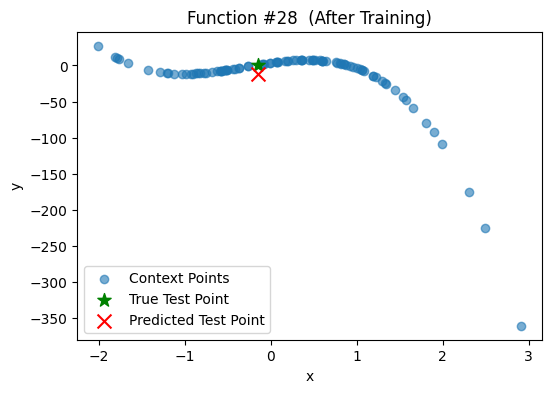

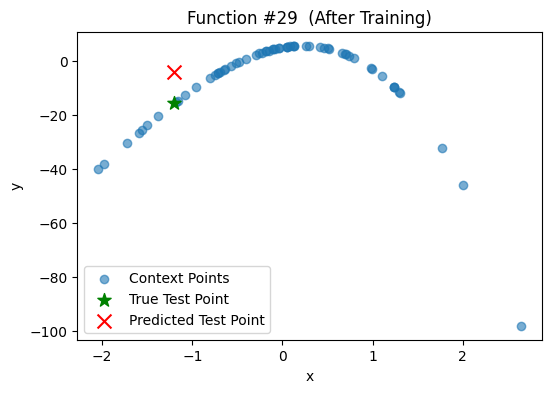

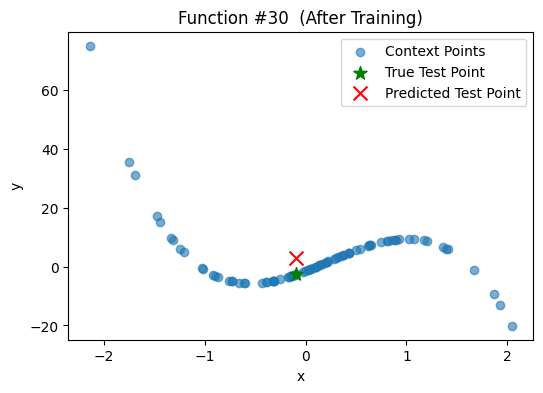

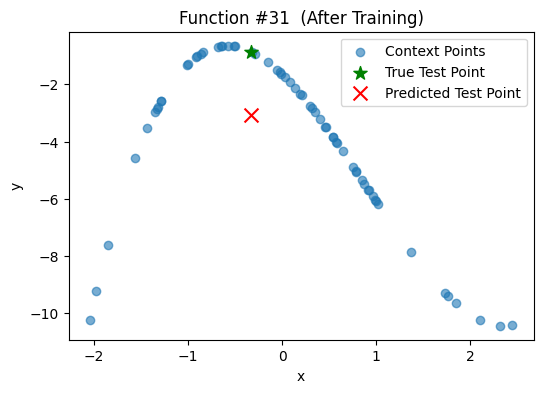

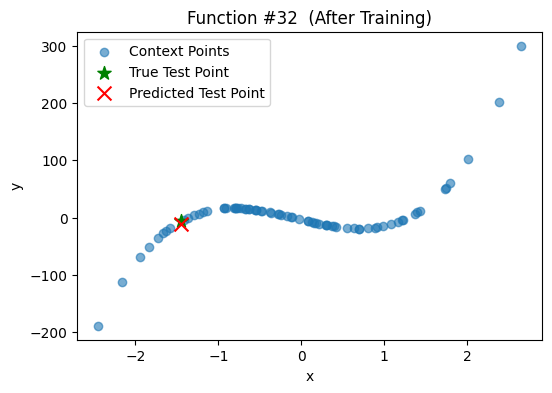

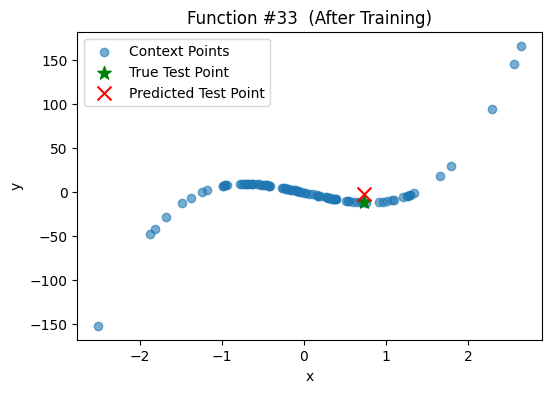

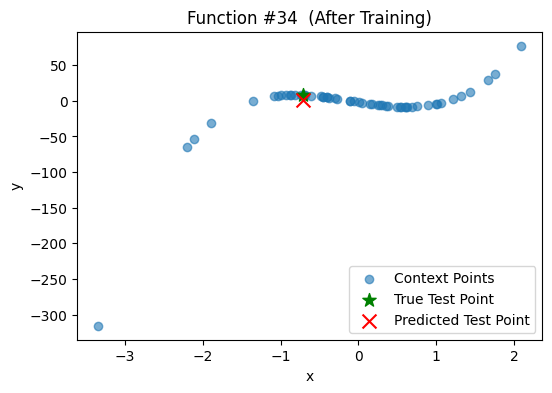

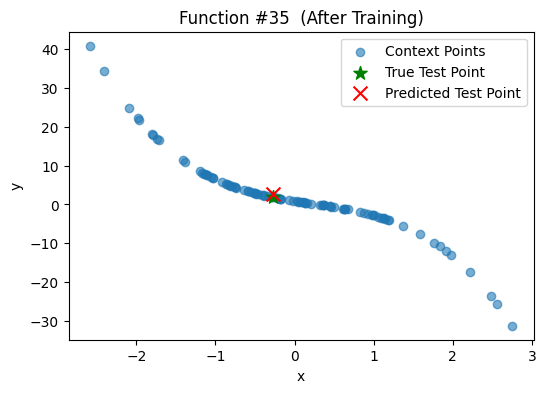

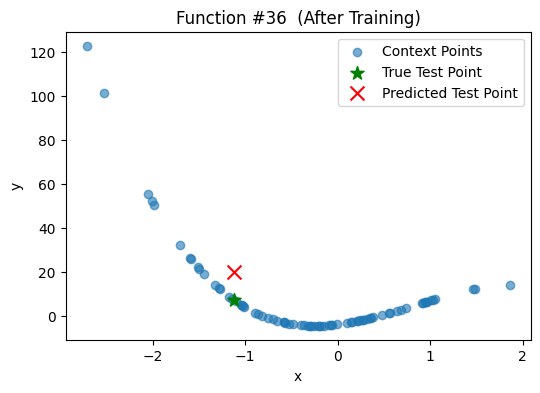

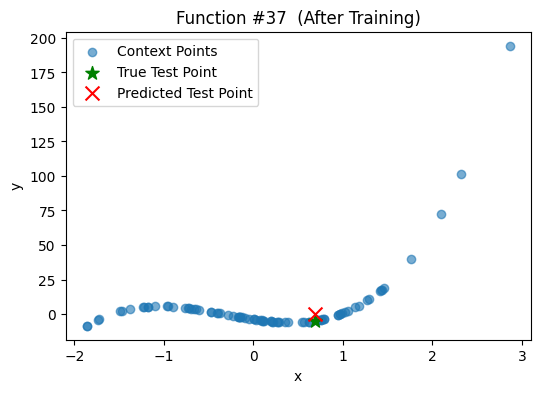

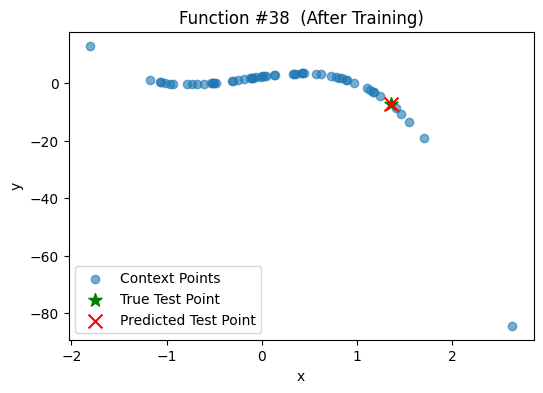

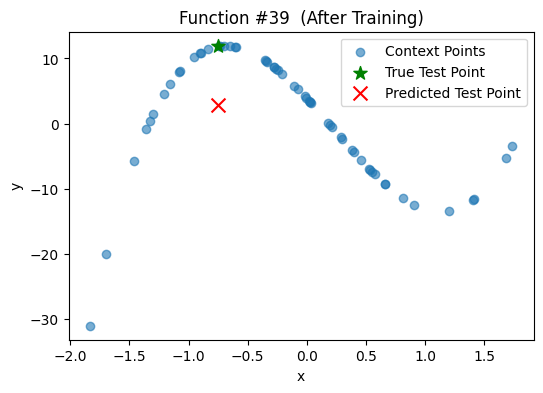

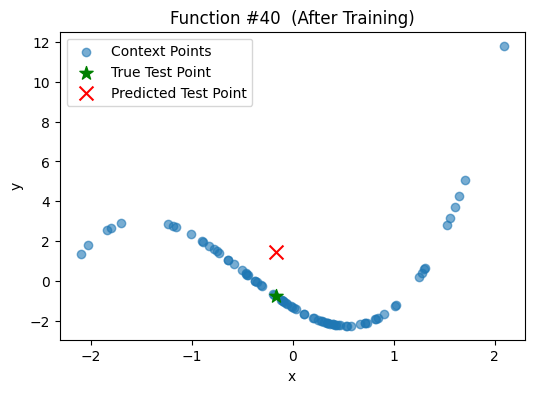

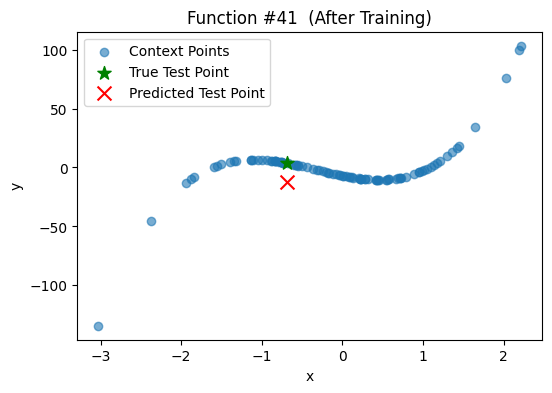

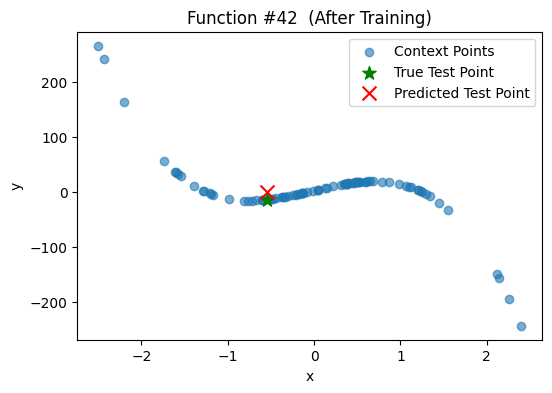

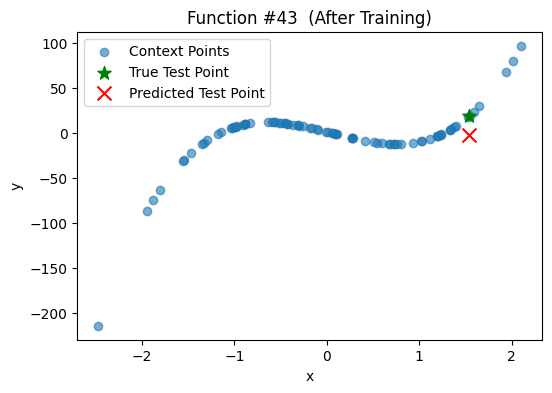

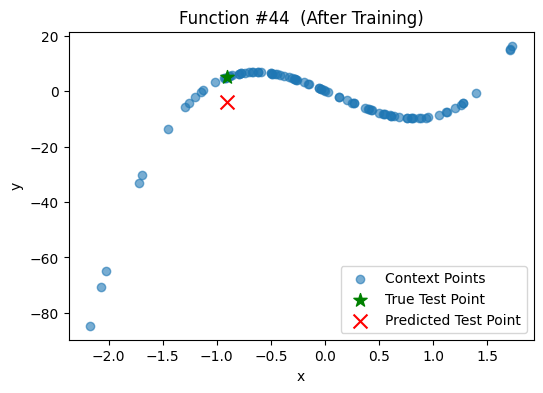

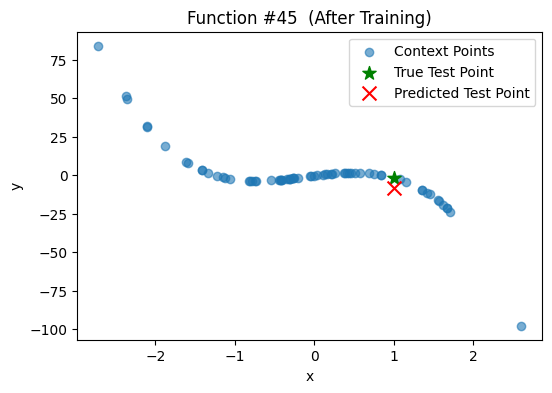

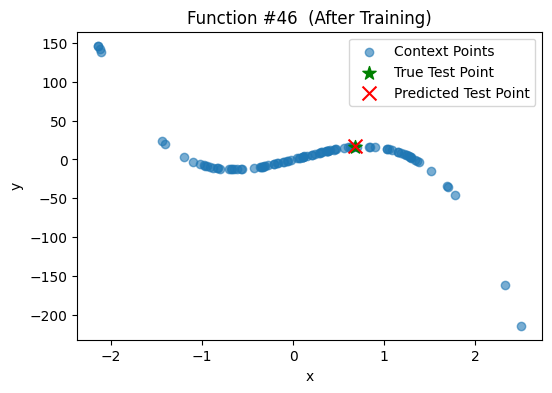

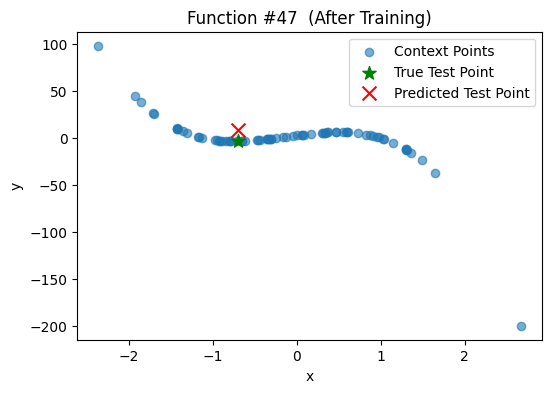

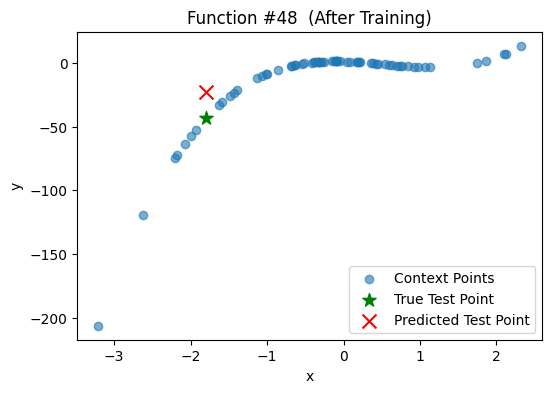

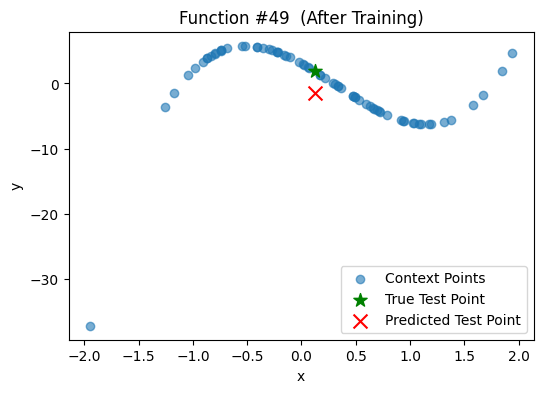

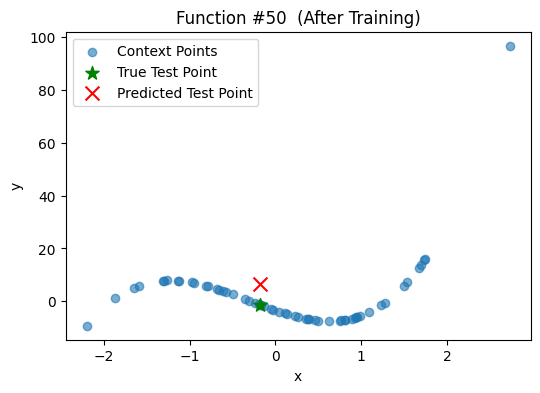

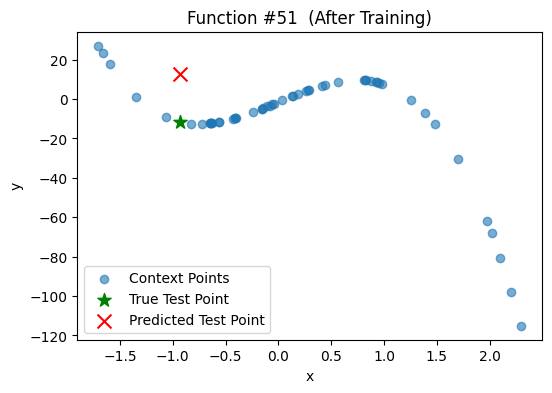

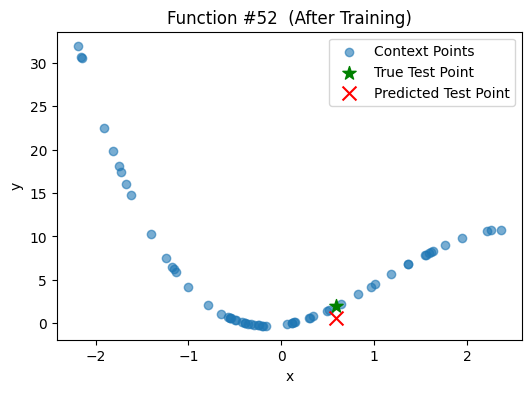

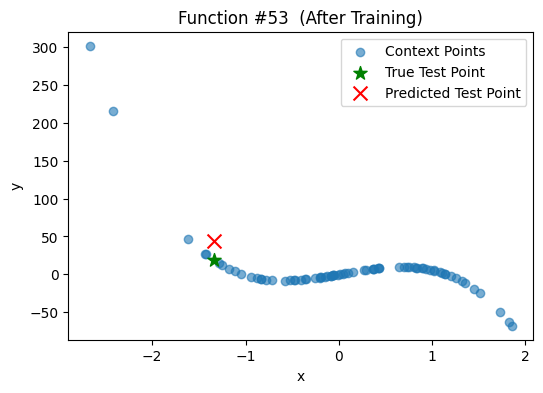

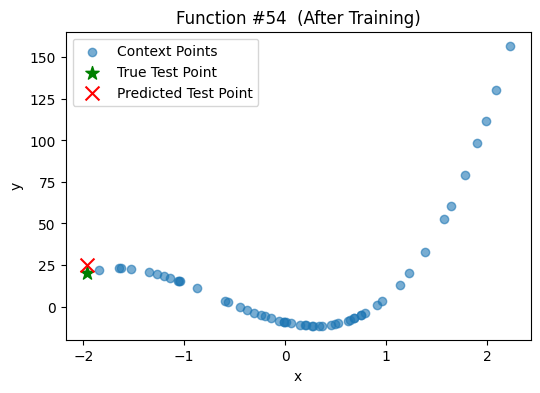

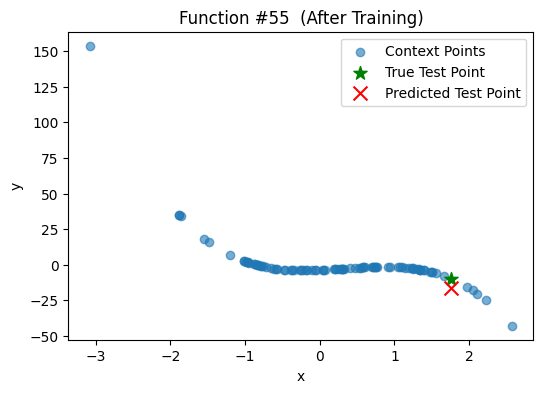

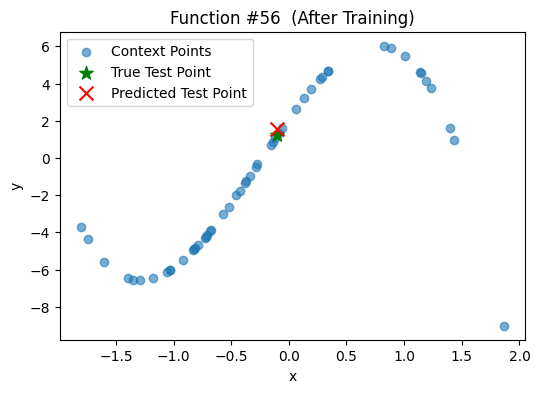

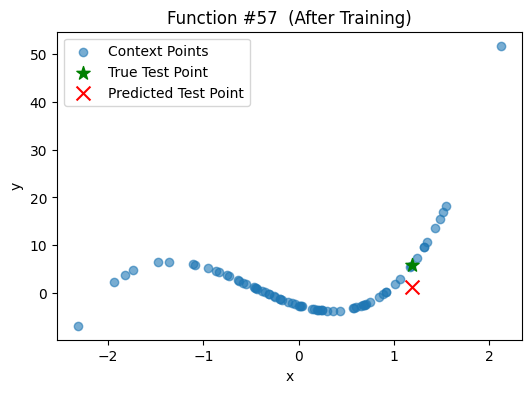

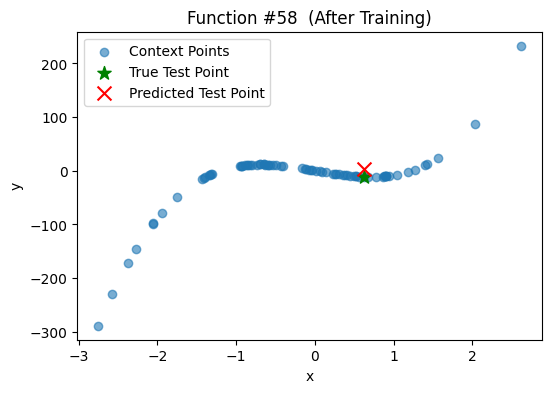

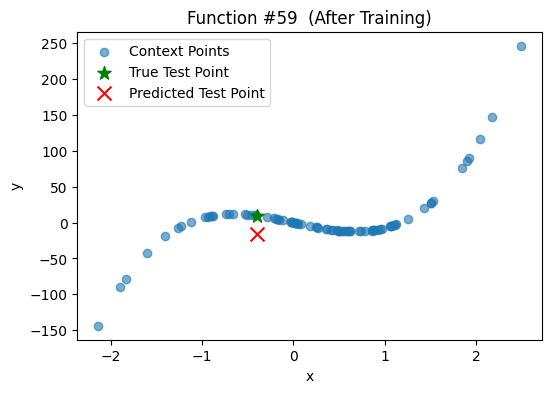

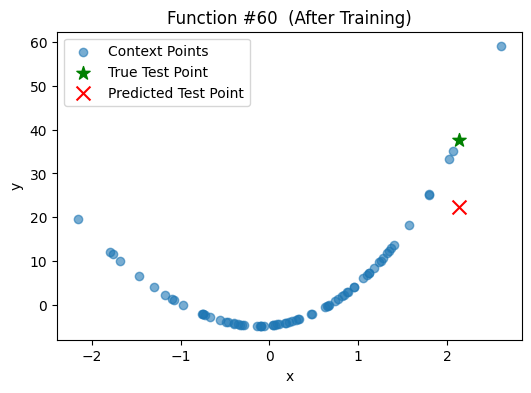

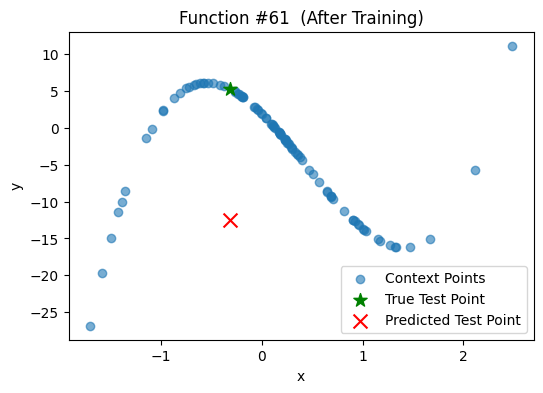

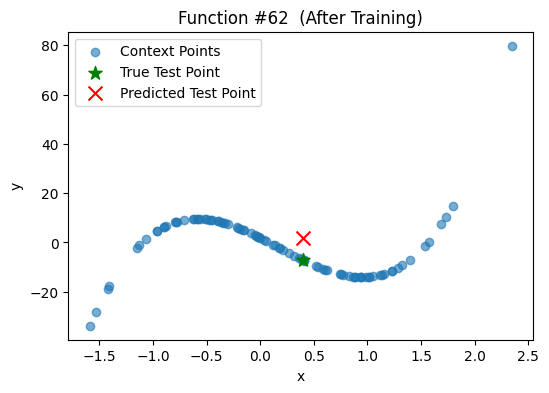

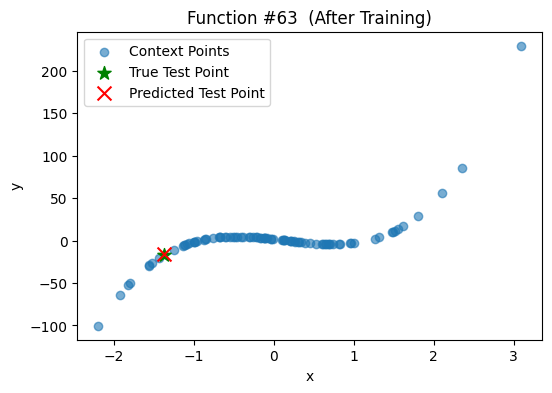

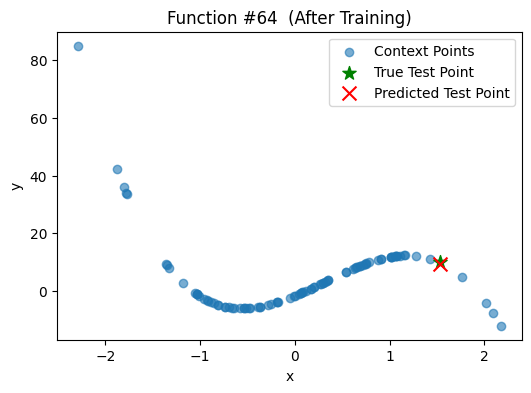

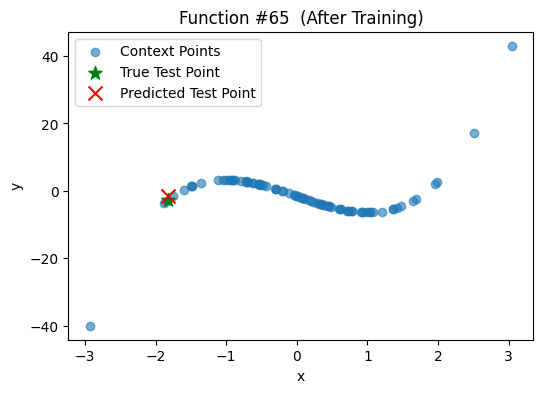

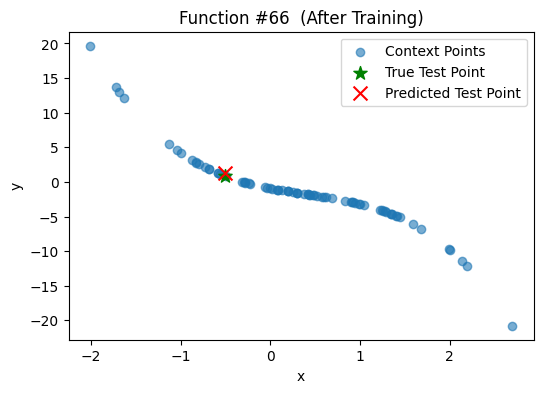

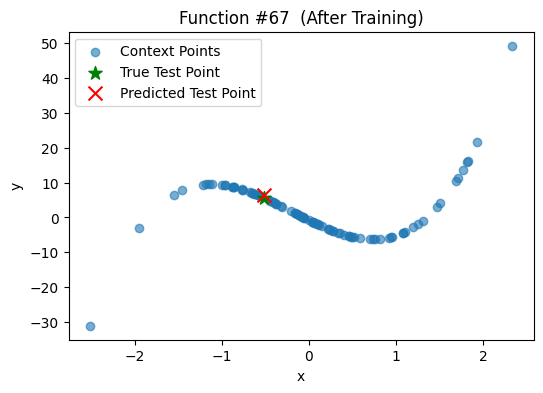

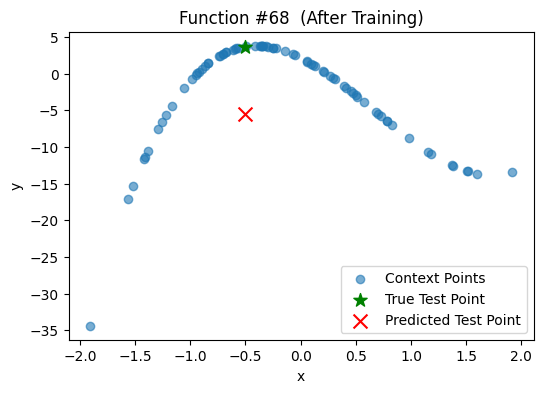

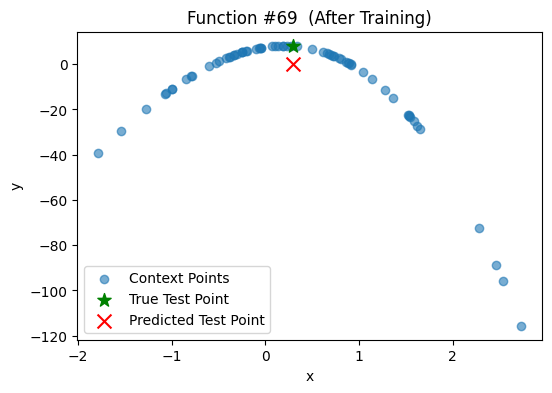

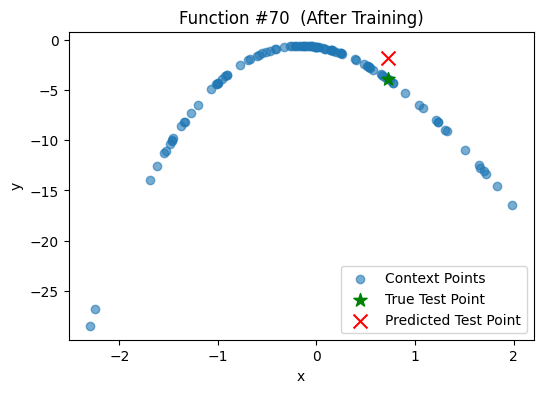

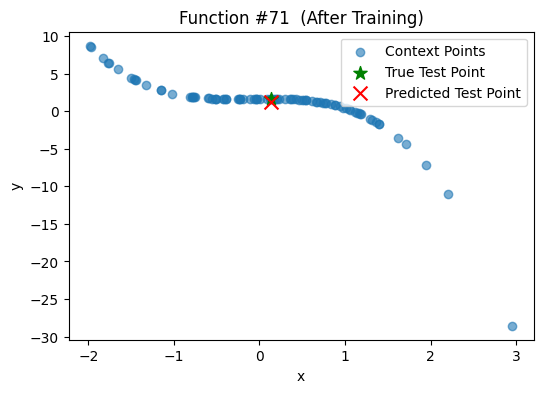

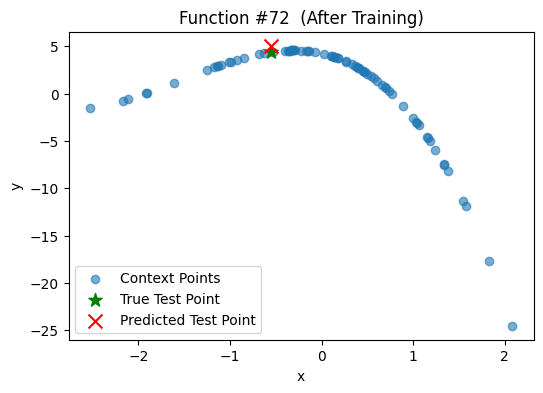

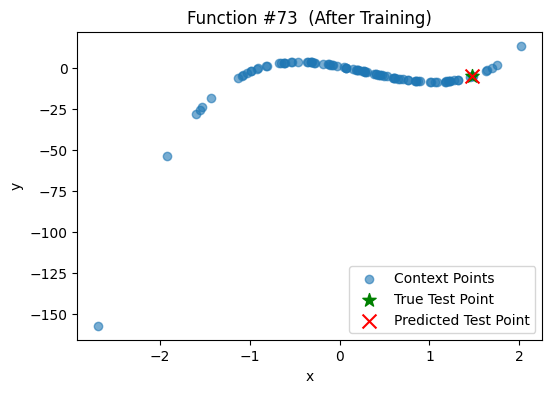

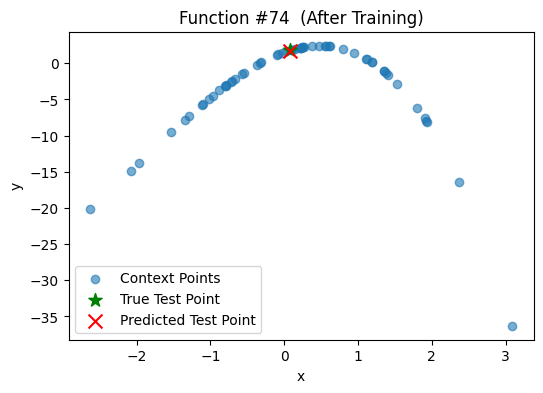

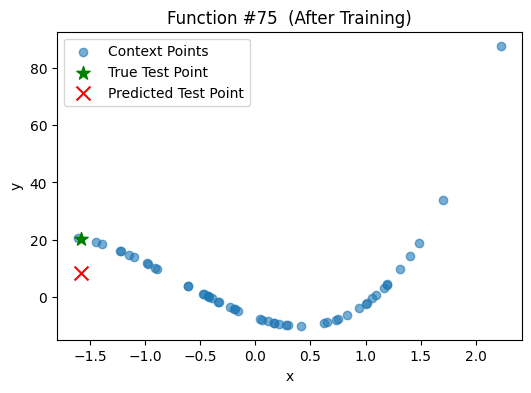

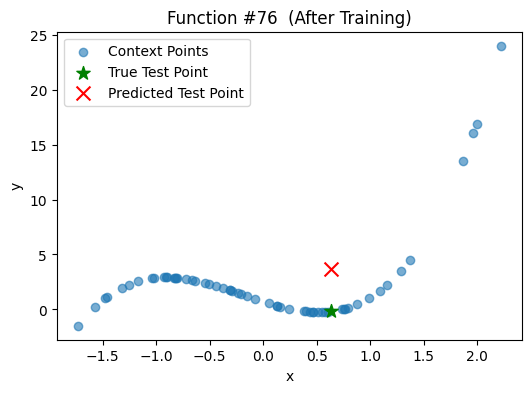

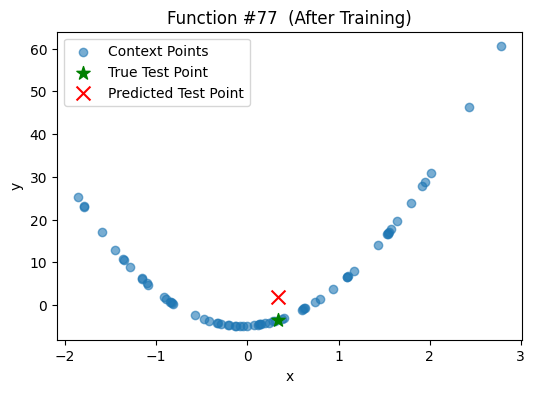

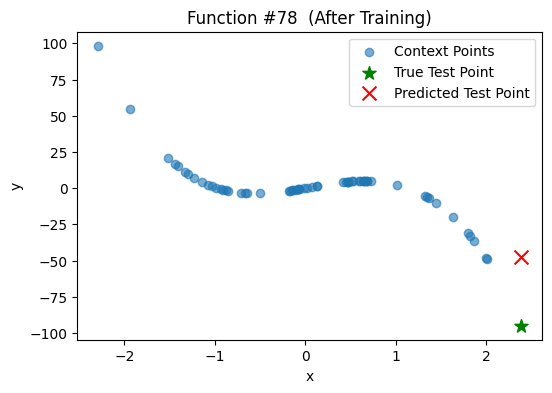

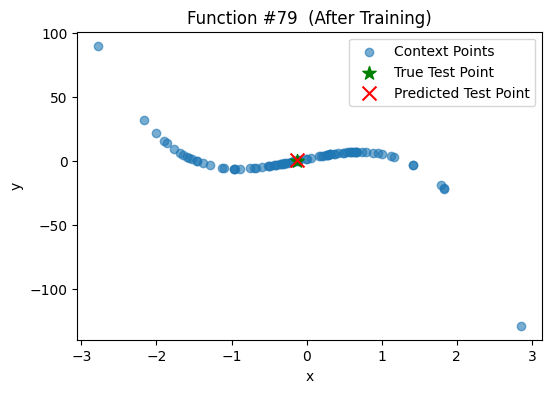

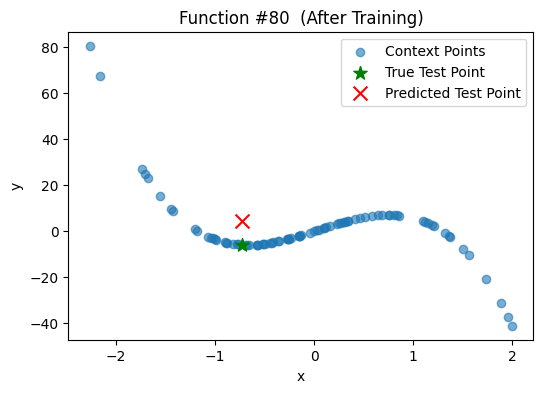

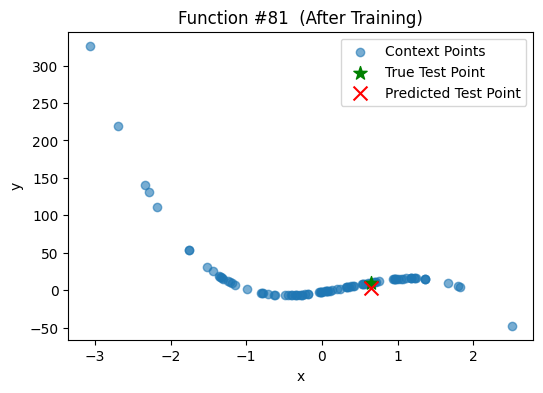

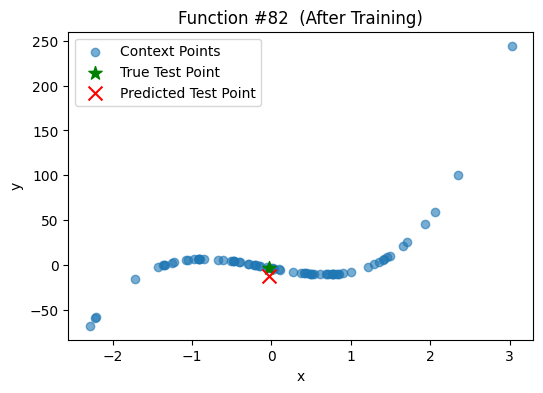

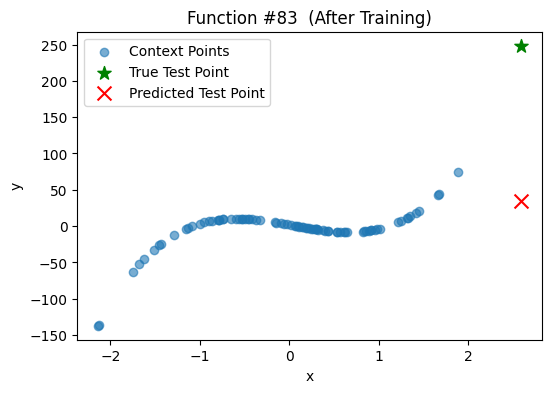

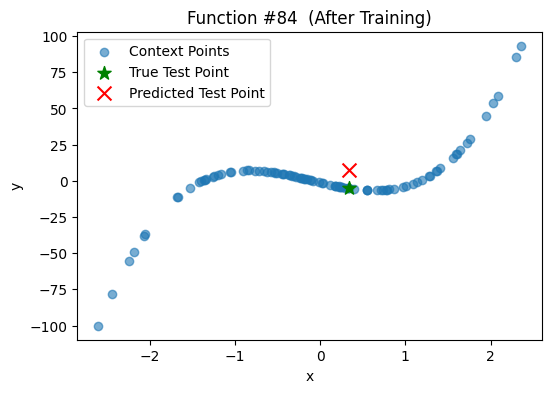

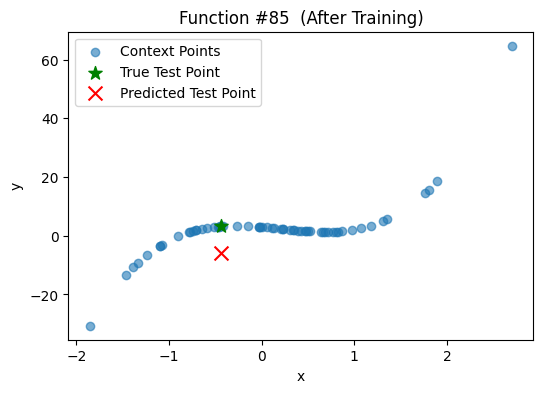

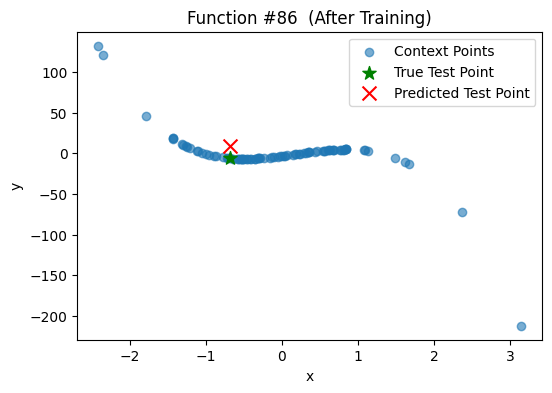

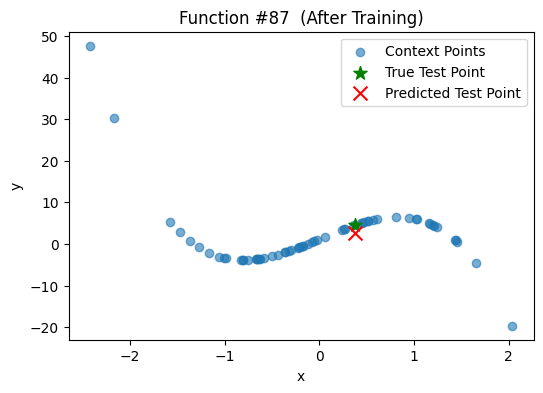

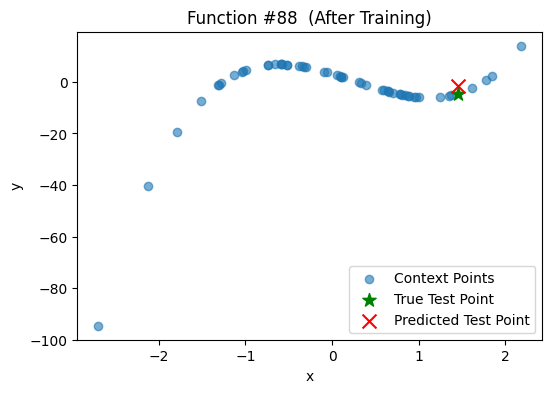

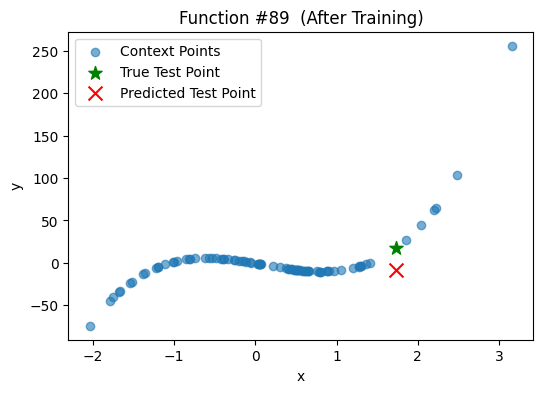

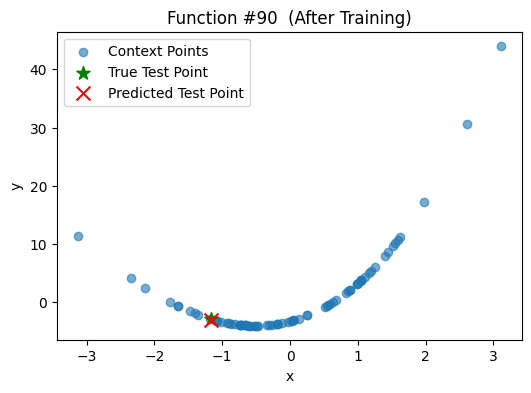

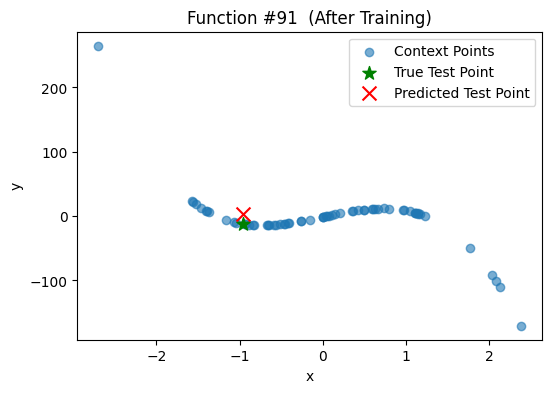

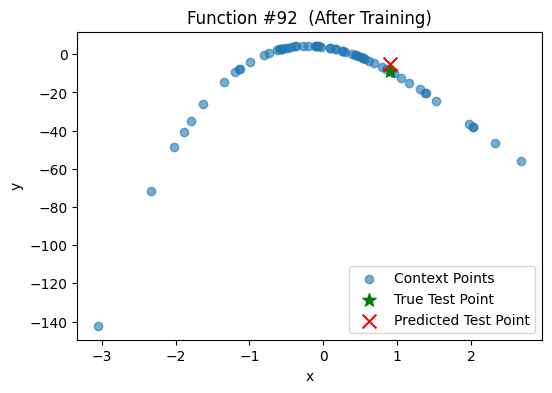

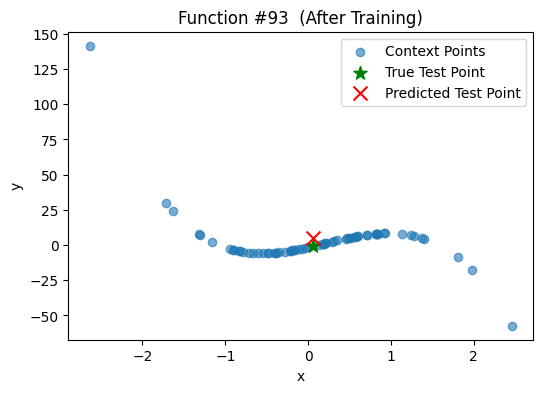

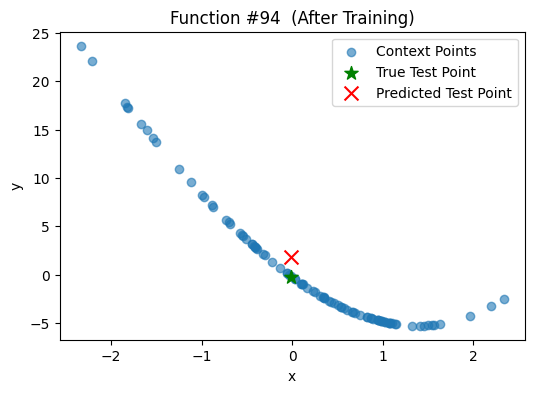

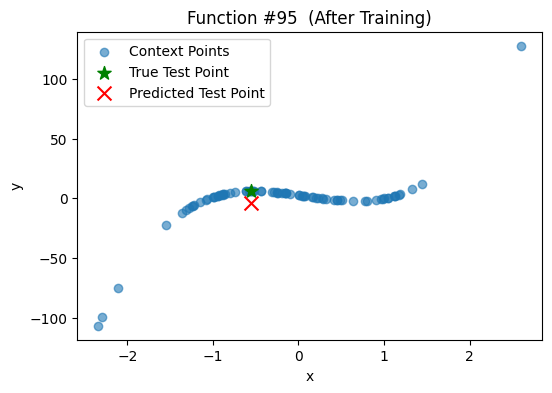

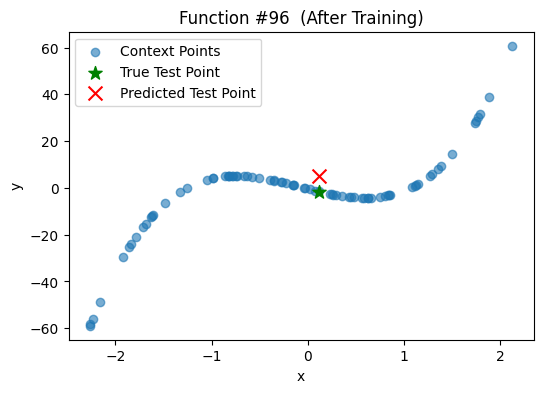

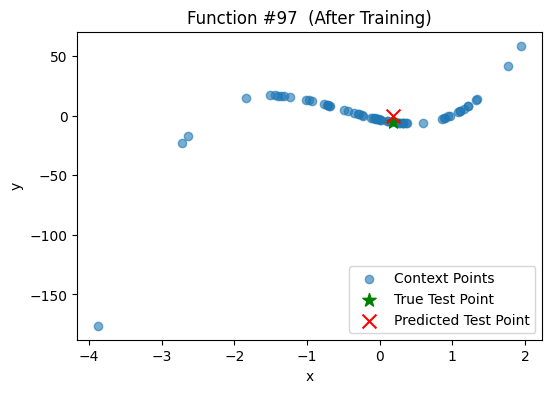

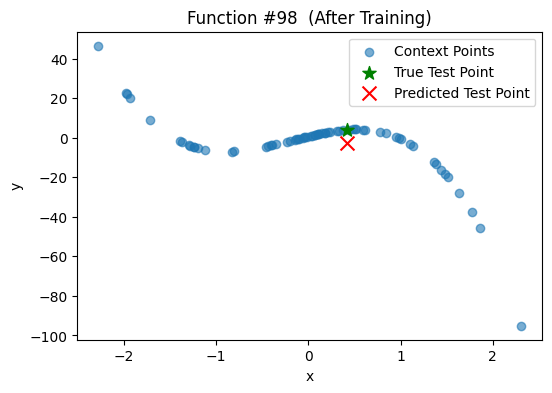

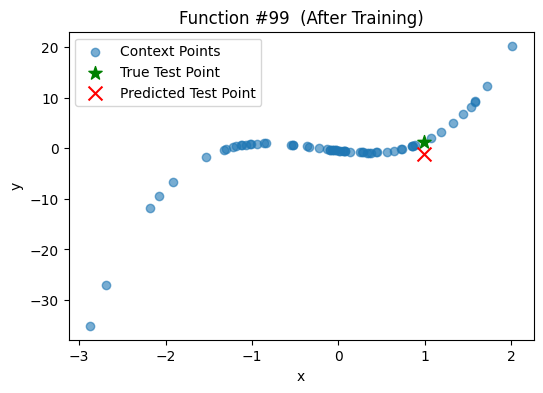

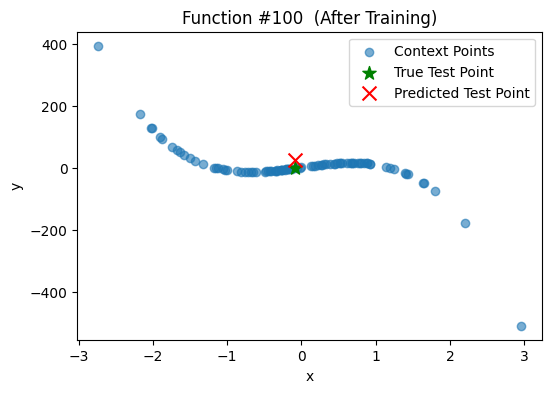

Test Function  1 → True y =  4.2564,  Predicted y =  22.6508,  |Error| =  18.3945
Test Function  2 → True y =  51.5422,  Predicted y = -20.7549,  |Error| =  72.2971
Test Function  3 → True y = -85.7803,  Predicted y =  30.3224,  |Error| =  116.1027
Test Function  4 → True y = -6.3852,  Predicted y = -1.2550,  |Error| =  5.1303
Test Function  5 → True y = -3.3047,  Predicted y =  3.7280,  |Error| =  7.0327
Test Function  6 → True y =  0.9223,  Predicted y = -9.5434,  |Error| =  10.4658
Test Function  7 → True y =  10.0758,  Predicted y =  29.3958,  |Error| =  19.3200
Test Function  8 → True y =  5.0688,  Predicted y =  25.2739,  |Error| =  20.2050
Test Function  9 → True y =  26.7042,  Predicted y =  61.5267,  |Error| =  34.8225
Test Function 10 → True y = -12.9670,  Predicted y = -0.8968,  |Error| =  12.0702

Mean absolute error over 10 test functions: 31.5841


In [23]:


# ─────────────────────────────────────────────────────────────────────────────
# 3) Single‐head causal self‐attention module
# ─────────────────────────────────────────────────────────────────────────────
class SingleHeadCausalSelfAttention(nn.Module):
    def __init__(self, input_dim=2, d_att=8):
        """
        input_dim: 2  (each context row is [x_i, y_i])
        d_att:      size of the attention embedding/output (must be > 2)
        """
        super().__init__()
        self.d_att = d_att
        self.W_Q = nn.Linear(input_dim, d_att, bias=False)
        self.W_K = nn.Linear(input_dim, d_att, bias=False)
        self.W_V = nn.Linear(input_dim, d_att, bias=False)

    def forward(self, context):
        """
        context: tensor of shape (n, 2) on the correct device.
        Returns:
          attn_out : shape (n, d_att) on the same device.
        """
        n = context.size(0)  # sequence length

        # Compute Q, K, V
        Q = self.W_Q(context)  # (n, d_att)
        K = self.W_K(context)  # (n, d_att)
        V = self.W_V(context)  # (n, d_att)

        # Raw scores: (n, n) = Q @ K^T / sqrt(d_att)
        scores = (Q @ K.transpose(0, 1)) / np.sqrt(self.d_att)

        # Causal mask: positions j > i should be −∞
        mask = torch.triu(torch.ones(n, n, device=context.device) * float("-inf"), diagonal=1)
        scores = scores + mask

        attn_weights = F.softmax(scores, dim=-1)  # (n, n)
        attn_out = attn_weights @ V               # (n, d_att)
        return attn_out

# ─────────────────────────────────────────────────────────────────────────────
# 4) Full “ContextPredictor” model = Attention → Pool → MLP
# ─────────────────────────────────────────────────────────────────────────────
class ContextPredictor(nn.Module):
    def __init__(self, d_att=8, d_proj=16, hidden_dim=32):
        """
        d_att:      attention embedding size
        d_proj:     dimension after projecting the averaged attention output
        hidden_dim: hidden‐layer size in the final MLP
        """
        super().__init__()
        self.attention = SingleHeadCausalSelfAttention(input_dim=2, d_att=d_att)
        self.proj_layer = nn.Linear(d_att, d_proj)
        self.hidden_layer = nn.Linear(d_proj + 1, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, context_x, context_y, x_test):
        """
        context_x: shape (n,) on device
        context_y: shape (n,) on device
        x_test:    shape (1,) on device
        Returns:
          y_pred: shape (1,) on device
        """
        # Stack context into shape (n, 2)
        context = torch.stack([context_x, context_y], dim=1)  # (n, 2)

        # (1) Self‐attention → (n, d_att)
        attn_out = self.attention(context)

        # (2) Aggregate by averaging over sequence length → (d_att,)
        agg = attn_out.mean(dim=0)

        # (3) Project to d_proj → (d_proj,)
        proj_vec = self.proj_layer(agg)

        # (4) Concatenate with x_test scalar → (d_proj + 1,)
        inp = torch.cat([proj_vec, x_test], dim=0)

        # (5) MLP: hidden + ReLU + output → (1,)
        h = F.relu(self.hidden_layer(inp))
        y_pred = self.output_layer(h)
        return y_pred

# ─────────────────────────────────────────────────────────────────────────────
# 5) Training + Plotting + Testing routine (now using `device`)
# ─────────────────────────────────────────────────────────────────────────────
def train_and_evaluate(
    num_train_functions=10,
    contexts_per_function=5,
    train_iterations=1000,
    test_functions=3,
    device=None
):
    """
    Trains on `num_train_functions` Hermite‐functions (each with `contexts_per_function` contexts).
    Each function is trained for `train_iterations` steps. Then plots the last training instance,
    and finally tests on `test_functions` new functions and prints errors.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")

    # Instantiate model and move to device
    model = ContextPredictor(d_att=8, d_proj=16, hidden_dim=32).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    last_context = None
    last_test_point = None
    last_prediction = None

    # ───────────────────────────────────────────────────────────
    # (A) TRAINING PHASE
    # ───────────────────────────────────────────────────────────
    for func_idx in range(num_train_functions):
        f = sample_hermite_function(device=device)

        # Pre‐sample all contexts for this function
        contexts = []
        for _ in range(contexts_per_function):
            n = np.random.randint(50, 101)
            context_x = torch.randn(n, device=device)
            context_y = f(context_x)
            x_test = torch.randn(1, device=device)
            y_test = f(x_test)
            contexts.append((context_x, context_y, x_test, y_test))

        # Run `train_iterations` updates for this function
        for _ in range(train_iterations):
            model.train()
            # Randomly pick one of the contexts
            idx = np.random.randint(contexts_per_function)
            context_x, context_y, x_test, y_test = contexts[idx]

            optimizer.zero_grad()
            y_pred = model(context_x, context_y, x_test).reshape(())
            loss = F.mse_loss(y_pred, y_test.reshape(()))
            loss.backward()
            optimizer.step()

        # plot the function after training for the last context just trained on:
        context_x, context_y, x_test, y_test = contexts[-1]
        model.eval()
        with torch.no_grad():
            y_pred_val = model(context_x, context_y, x_test).item()
        last_context = (context_x.cpu(), context_y.cpu())
        last_test_point = (x_test.item(), y_test.item())
        last_prediction = y_pred_val
        # ───────────────────────────────────────────────────────────
        # (B) PLOTTING the last training instance
        # ───────────────────────────────────────────────────────────
        ctx_x, ctx_y = last_context
        tx, ty = last_test_point
        yp = last_prediction

        

        plt.figure(figsize=(6, 4))
        plt.scatter(ctx_x.numpy(), ctx_y.numpy(), label="Context Points", alpha=0.6)
        plt.scatter([tx], [ty], color="green", marker="*", s=100, label="True Test Point")
        plt.scatter([tx], [yp], color="red", marker="x", s=100, label="Predicted Test Point")
        plt.title(f"Function #{func_idx+1}  (After Training)")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

    # ───────────────────────────────────────────────────────────
    # (C) TESTING PHASE on new Hermite‐functions
    # ───────────────────────────────────────────────────────────
    errors = []
    for test_idx in range(test_functions):
        f_test = sample_hermite_function(device=device)
        n = np.random.randint(50, 101)
        context_x = torch.randn(n, device=device)
        context_y = f_test(context_x)
        x_test = torch.randn(1, device=device)
        y_true = f_test(x_test).item()

        model.eval()
        with torch.no_grad():
            y_pred = model(context_x, context_y, x_test).item()

        abs_err = abs(y_pred - y_true)
        errors.append(abs_err)
        print(
            f"Test Function {test_idx+1:2d} → "
            f"True y = {y_true: .4f},  "
            f"Predicted y = {y_pred: .4f},  "
            f"|Error| = {abs_err: .4f}"
        )

    print(f"\nMean absolute error over {test_functions} test functions: {np.mean(errors):.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# Run it!  (Start small to verify, then scale up)
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    train_and_evaluate(
        num_train_functions=100,    # ← set to 1000 for full run
        contexts_per_function=50,
        train_iterations=1000,     # ← set to 10000 for full run
        test_functions=10,          # ← set to 10 for full run
        device=device
    )
